In [1]:
packages <- c("ggplot2", "dplyr", "tidyr")
for (pkg in packages) {
    suppressMessages(
        suppressWarnings(
            library(pkg, character.only = TRUE)
    )   )
}

In [2]:
results_dir <- file.path("../model_results/")
pattern = glob2rx("*model_performance*")
# glob all the model results files
model_results_files <- list.files(
  results_dir,
  pattern = pattern,
  full.names = FALSE,
  recursive = TRUE
)
print(paste("Found", length(model_results_files), "model results files."))

pattern = glob2rx("*feature_importances*")
# glob all the model results files
profiles_feature_importances_results_files <- list.files(
  results_dir,
  pattern = pattern,
  full.names = FALSE,
  recursive = TRUE
)
print(paste("Found", length(profiles_feature_importances_results_files), "feature importances files."))


pattern = glob2rx("*predicted_viabilities*")
# glob all the model results files
profiles_predicted_viabilities_results_files <- list.files(
  results_dir,
  pattern = pattern,
  full.names = FALSE,
  recursive = TRUE
)
print(paste("Found", length(profiles_predicted_viabilities_results_files), "predicted viabilities files."))

[1] "Found 24 model results files."
[1] "Found 24 feature importances files."
[1] "Found 24 predicted viabilities files."


In [3]:
list_of_model_results_dataframes <- list()
for (file in model_results_files) {
    # load each model results file
    df <- arrow::read_parquet(file.path(results_dir, file))
    df$profile_type <- gsub("_profiles_model_performance\\.parquet", "", file)
    list_of_model_results_dataframes[[file]] <- df
}
# concatenate all the dataframes into one
model_results_df <- do.call(rbind, list_of_model_results_dataframes)
# split each string in the profile_type column by "_" and return a list of vectors
# get the first element of each vector and assign it to a new column called data_split_strategy
model_results_df$data_split_strategy <- sapply(
    strsplit(model_results_df$profile_type, "_"),
    function(x) x[1]
)
# get the last two elements of each vector and assign it to a new column called model_type
model_results_df$shuffled <- sapply(
    strsplit(model_results_df$profile_type, "_"),
    function(x) paste(x[(length(x)-1):length(x)], collapse = "_")
)
model_results_df$shuffled <- gsub(".parquet", "", model_results_df$shuffled)


list_of_feature_importance_dataframes <- list()
for (file in profiles_feature_importances_results_files) {
    # load each model results file
    df <- arrow::read_parquet(file.path(results_dir, file))
    df$profile_type <- gsub("_profiles_feature_importances\\.parquet", "", file)
    list_of_feature_importance_dataframes[[file]] <- df
}
# concatenate all the dataframes into one
feature_importances_df <- do.call(rbind, list_of_feature_importance_dataframes)
feature_importances_df$data_split_strategy <- sapply(
    strsplit(feature_importances_df$profile_type, "_"),
    function(x) x[1]
)
feature_importances_df$shuffled <- sapply(
    strsplit(feature_importances_df$profile_type, "_"),
    function(x) paste(x[(length(x)-1):length(x)], collapse = "_")
)
feature_importances_df$shuffled <- gsub(".parquet", "", feature_importances_df$shuffled)

list_of_predicted_viabilities_dataframes <- list()
for (file in profiles_predicted_viabilities_results_files) {
    # load each model results file
    df <- arrow::read_parquet(file.path(results_dir, file))
    metadata_column_names <- df %>%
        select(starts_with("Metadata_")) %>%
        # column does not contain "cqc" in the name
        select(-contains("cqc")) %>%
        colnames()
    viability_column_names <- c("Predicted_Viability", "Actual_Viability")
    # drop all columns except for the metadata columns and the predicted viability column
    df <- df %>%
        select(all_of(c(metadata_column_names, viability_column_names)))

    df$profile_type <- gsub("_profiles_predicted_viabilities\\.parquet", "", file)
    print(dim(df))
    list_of_predicted_viabilities_dataframes[[file]] <- df  
}
# concatenate all the dataframes into one
predicted_viabilities_df <- do.call(rbind, list_of_predicted_viabilities_dataframes)
predicted_viabilities_df$data_split_strategy <- sapply(
    strsplit(predicted_viabilities_df$profile_type, "__"),
    function(x) x[1]
)
predicted_viabilities_df$data_split_strategy <- sapply(
    strsplit(predicted_viabilities_df$data_split_strategy, "_"),
    function(x) x[1]
)
predicted_viabilities_df$shuffled <- sapply(
    strsplit(predicted_viabilities_df$profile_type, "__"),
    function(x) x[2]
)
predicted_viabilities_df$shuffled <- gsub(".parquet", "", predicted_viabilities_df$shuffled)    


[1] 24 13
[1] 24 13
[1] 24 13
[1] 24 13
[1] 24 13
[1] 24 13
[1] 24 13
[1] 24 13
[1] 24 13
[1] 24 13
[1] 24 13
[1] 24 13
[1]  8 13
[1]  8 13
[1]  8 13
[1]  8 13
[1]  8 13
[1]  8 13
[1]  8 13
[1]  8 13
[1]  8 13
[1]  8 13
[1]  8 13
[1]  8 13


In [4]:
head(predicted_viabilities_df)

Metadata_Biology_PatientTumor,Metadata_Experiment_Treatment,Metadata_Experiment_Dose,Metadata_Experiment_Class,Metadata_Experiment_Target,Metadata_Experiment_TherapeuticCategories,Metadata_Experiment_Unit,Metadata_Experiment_FullTreatment,Metadata_fold,Metadata_held_out_group,Predicted_Viability,Actual_Viability,profile_type,data_split_strategy,shuffled
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
NF0014_T1,Staurosporine,10,Small Molecule,Apoptosis induction,Experimental,nM,Staurosporine_10,0,NF0014_T1,37.91108,5.515339,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T1,Linsitinib,1,Small Molecule,IGF-1R inhibitor,Investigational,uM,Linsitinib_1,0,NF0014_T1,73.30146,79.531230,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T1,Copanlisib,1,Small Molecule,PI3K inhibitor,Kinase Inhibitor,uM,Copanlisib_1,0,NF0014_T1,46.10071,45.043833,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T2,Mirdametinib,1,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,uM,Mirdametinib_1,1,NF0014_T2,57.65888,80.777050,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T2,Selumetinib,10,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,uM,Selumetinib_10,1,NF0014_T2,57.06226,124.056923,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T2,DMSO,1,Control,Control,Control,%,DMSO_1,1,NF0014_T2,94.13086,100.000000,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled


In [5]:
head(model_results_df)

Metadata_fold,Metadata_held_out_group,Metadata_eval_split,Metadata_n_samples,R2,MSE,MAE,MAPE,RMSE,profile_type,data_split_strategy,shuffled
<int>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
0,NF0014_T1,train,21,0.8399686,258.0320,10.079902,58.82251,16.06337,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles
0,NF0014_T1,test,3,0.6028992,363.1370,13.227461,199.18492,19.05615,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles
1,NF0014_T2,train,21,0.8726514,223.0348,8.802175,53.34471,14.93435,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles
1,NF0014_T2,test,3,-4.3773012,1685.7271,31.993991,29.49734,41.05761,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles
2,NF0018_T6,train,18,0.8477318,293.2281,10.709097,59.58965,17.12390,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles
2,NF0018_T6,test,6,0.1692591,721.2420,20.232803,130.10040,26.85595,lopo_model_performance__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles


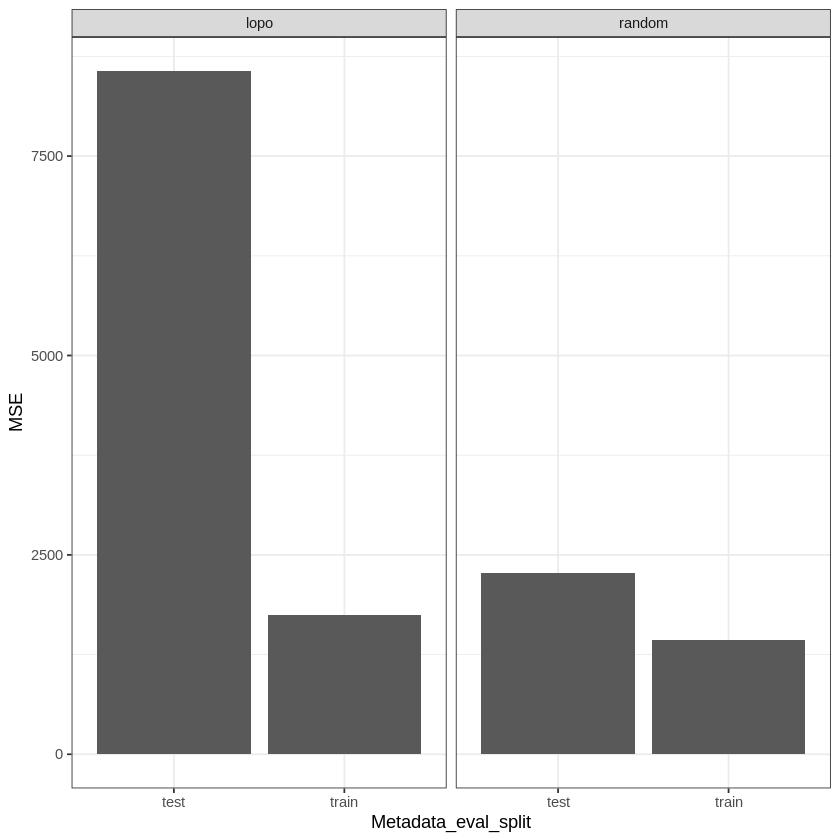

In [6]:
# plot the model performance metrics for each profile type
model_performance_plot <- (
    ggplot(model_results_df, aes(x = Metadata_eval_split, y = MSE)) 
    + geom_bar(stat = "identity", position = "dodge")
    + facet_wrap(~data_split_strategy)
    + theme_bw()

)
model_performance_plot

In [7]:
head(feature_importances_df)
feature_importances_df$importance_abs <- abs(feature_importances_df$importance)
# get the top 2 features by absolute importance for each profile type
top_features_df <- feature_importances_df %>%
    group_by(profile_type) %>%
    top_n(2, importance_abs) %>%
    ungroup() %>%
    arrange(profile_type, desc(importance_abs))

feature,importance,Metadata_fold,Metadata_held_out_group,Metadata_shuffle_status,profile_type,data_split_strategy,shuffled
<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
Nucleocentric_AGP_CHAMMI75_Feature0,0,0,NF0014_T1,not_shuffled,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles
Nucleocentric_AGP_CHAMMI75_Feature1,0,0,NF0014_T1,not_shuffled,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles
Nucleocentric_AGP_CHAMMI75_Feature10,0,0,NF0014_T1,not_shuffled,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles
Nucleocentric_AGP_CHAMMI75_Feature100,0,0,NF0014_T1,not_shuffled,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles
Nucleocentric_AGP_CHAMMI75_Feature101,0,0,NF0014_T1,not_shuffled,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles
Nucleocentric_AGP_CHAMMI75_Feature102,0,0,NF0014_T1,not_shuffled,lopo_feature_importances__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,consensus_profiles


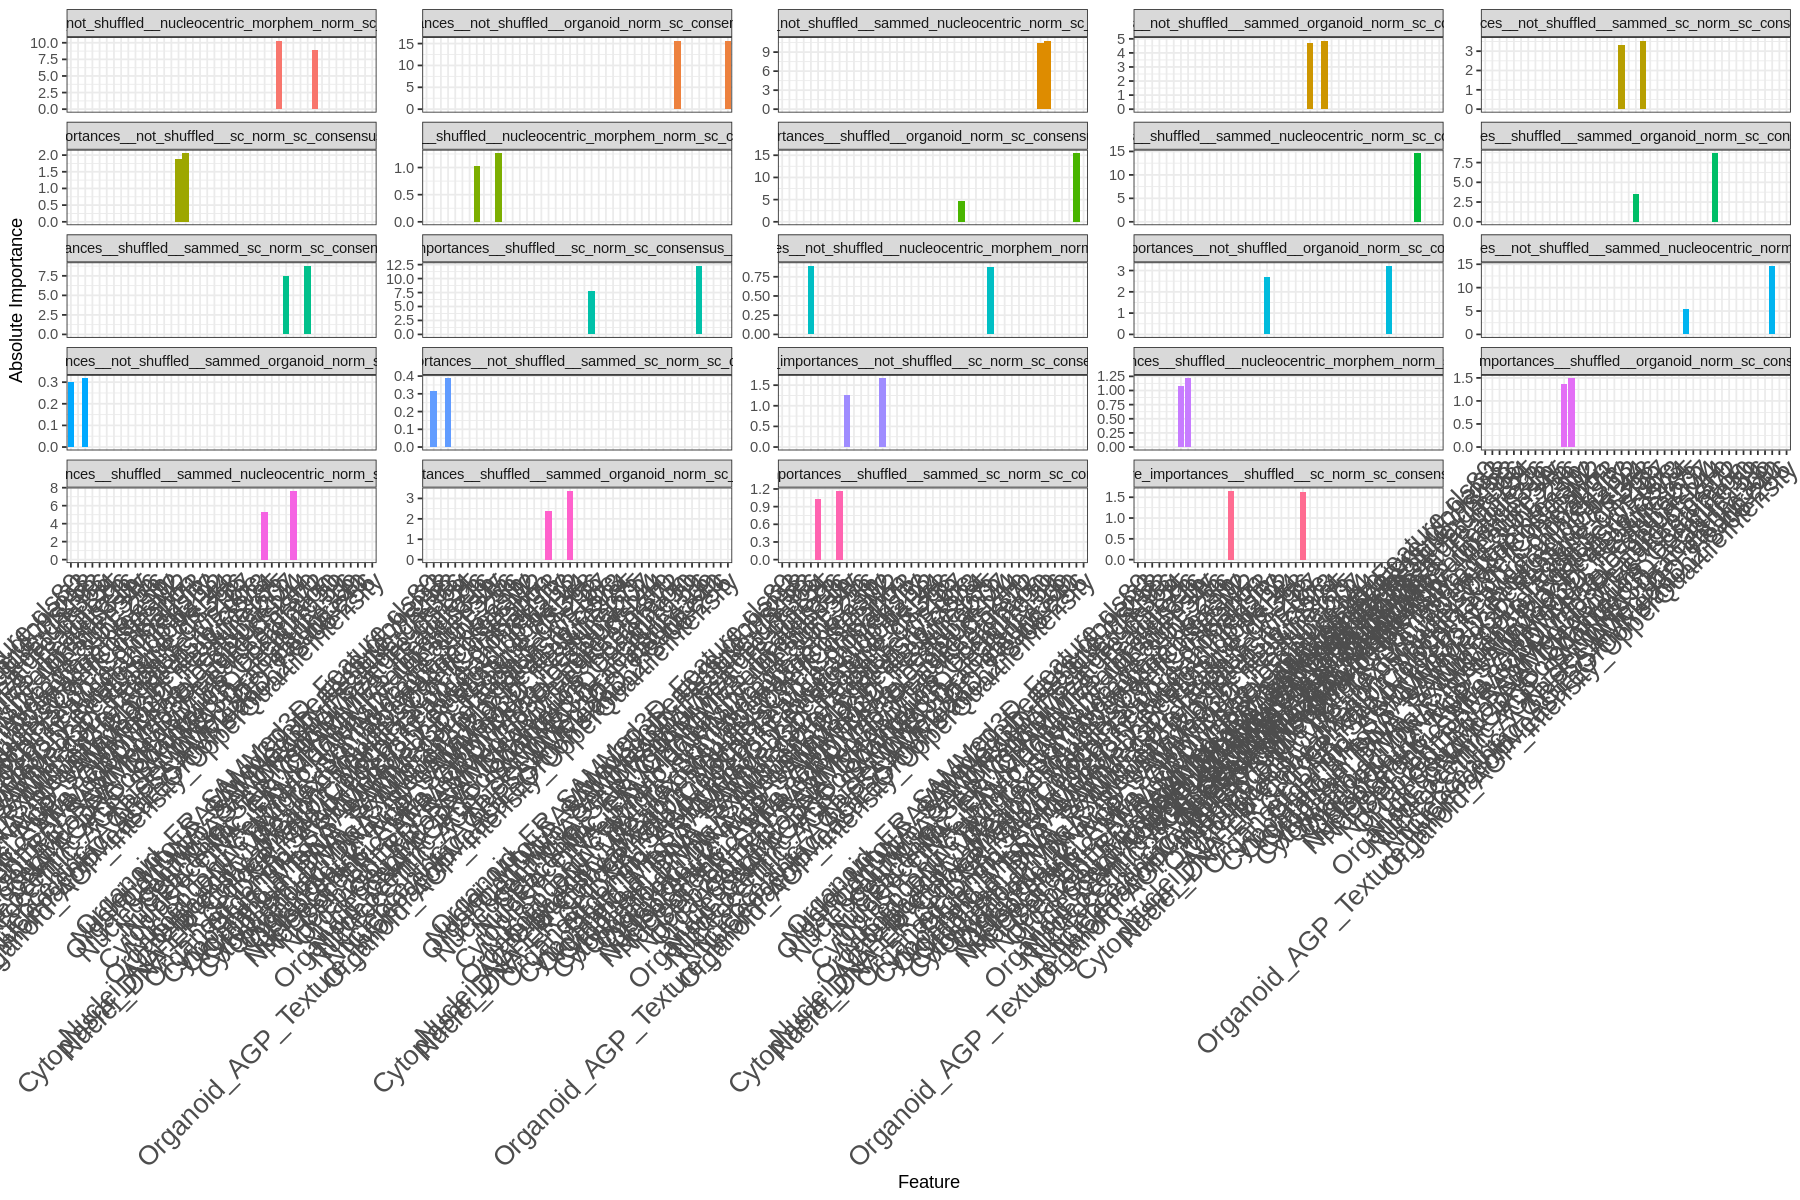

In [8]:
height <- 10
width <- 15
options(repr.plot.width = width, repr.plot.height = height)
feature_importances_plot <- (
    ggplot(top_features_df, aes(x = reorder(feature, importance_abs), y = importance_abs, fill = profile_type))
    + geom_bar(stat = "identity", position = "dodge")
    + facet_wrap(~profile_type, scales = "free_y")
    + theme_bw()
    + labs(x = "Feature", y = "Absolute Importance")
    + theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 16))
    + theme(legend.position = "none")
)
feature_importances_plot

In [9]:
head(predicted_viabilities_df)

Metadata_Biology_PatientTumor,Metadata_Experiment_Treatment,Metadata_Experiment_Dose,Metadata_Experiment_Class,Metadata_Experiment_Target,Metadata_Experiment_TherapeuticCategories,Metadata_Experiment_Unit,Metadata_Experiment_FullTreatment,Metadata_fold,Metadata_held_out_group,Predicted_Viability,Actual_Viability,profile_type,data_split_strategy,shuffled
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
NF0014_T1,Staurosporine,10,Small Molecule,Apoptosis induction,Experimental,nM,Staurosporine_10,0,NF0014_T1,37.91108,5.515339,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T1,Linsitinib,1,Small Molecule,IGF-1R inhibitor,Investigational,uM,Linsitinib_1,0,NF0014_T1,73.30146,79.531230,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T1,Copanlisib,1,Small Molecule,PI3K inhibitor,Kinase Inhibitor,uM,Copanlisib_1,0,NF0014_T1,46.10071,45.043833,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T2,Mirdametinib,1,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,uM,Mirdametinib_1,1,NF0014_T2,57.65888,80.777050,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T2,Selumetinib,10,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,uM,Selumetinib_10,1,NF0014_T2,57.06226,124.056923,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T2,DMSO,1,Control,Control,Control,%,DMSO_1,1,NF0014_T2,94.13086,100.000000,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled


In [10]:
head(predicted_viabilities_df)

Metadata_Biology_PatientTumor,Metadata_Experiment_Treatment,Metadata_Experiment_Dose,Metadata_Experiment_Class,Metadata_Experiment_Target,Metadata_Experiment_TherapeuticCategories,Metadata_Experiment_Unit,Metadata_Experiment_FullTreatment,Metadata_fold,Metadata_held_out_group,Predicted_Viability,Actual_Viability,profile_type,data_split_strategy,shuffled
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
NF0014_T1,Staurosporine,10,Small Molecule,Apoptosis induction,Experimental,nM,Staurosporine_10,0,NF0014_T1,37.91108,5.515339,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T1,Linsitinib,1,Small Molecule,IGF-1R inhibitor,Investigational,uM,Linsitinib_1,0,NF0014_T1,73.30146,79.531230,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T1,Copanlisib,1,Small Molecule,PI3K inhibitor,Kinase Inhibitor,uM,Copanlisib_1,0,NF0014_T1,46.10071,45.043833,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T2,Mirdametinib,1,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,uM,Mirdametinib_1,1,NF0014_T2,57.65888,80.777050,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T2,Selumetinib,10,Small Molecule,MEK1/2 inhibitor,Kinase Inhibitor,uM,Selumetinib_10,1,NF0014_T2,57.06226,124.056923,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled
NF0014_T2,DMSO,1,Control,Control,Control,%,DMSO_1,1,NF0014_T2,94.13086,100.000000,lopo_predicted_viabilities__not_shuffled__nucleocentric_morphem_norm_sc_consensus_profiles.parquet,lopo,not_shuffled


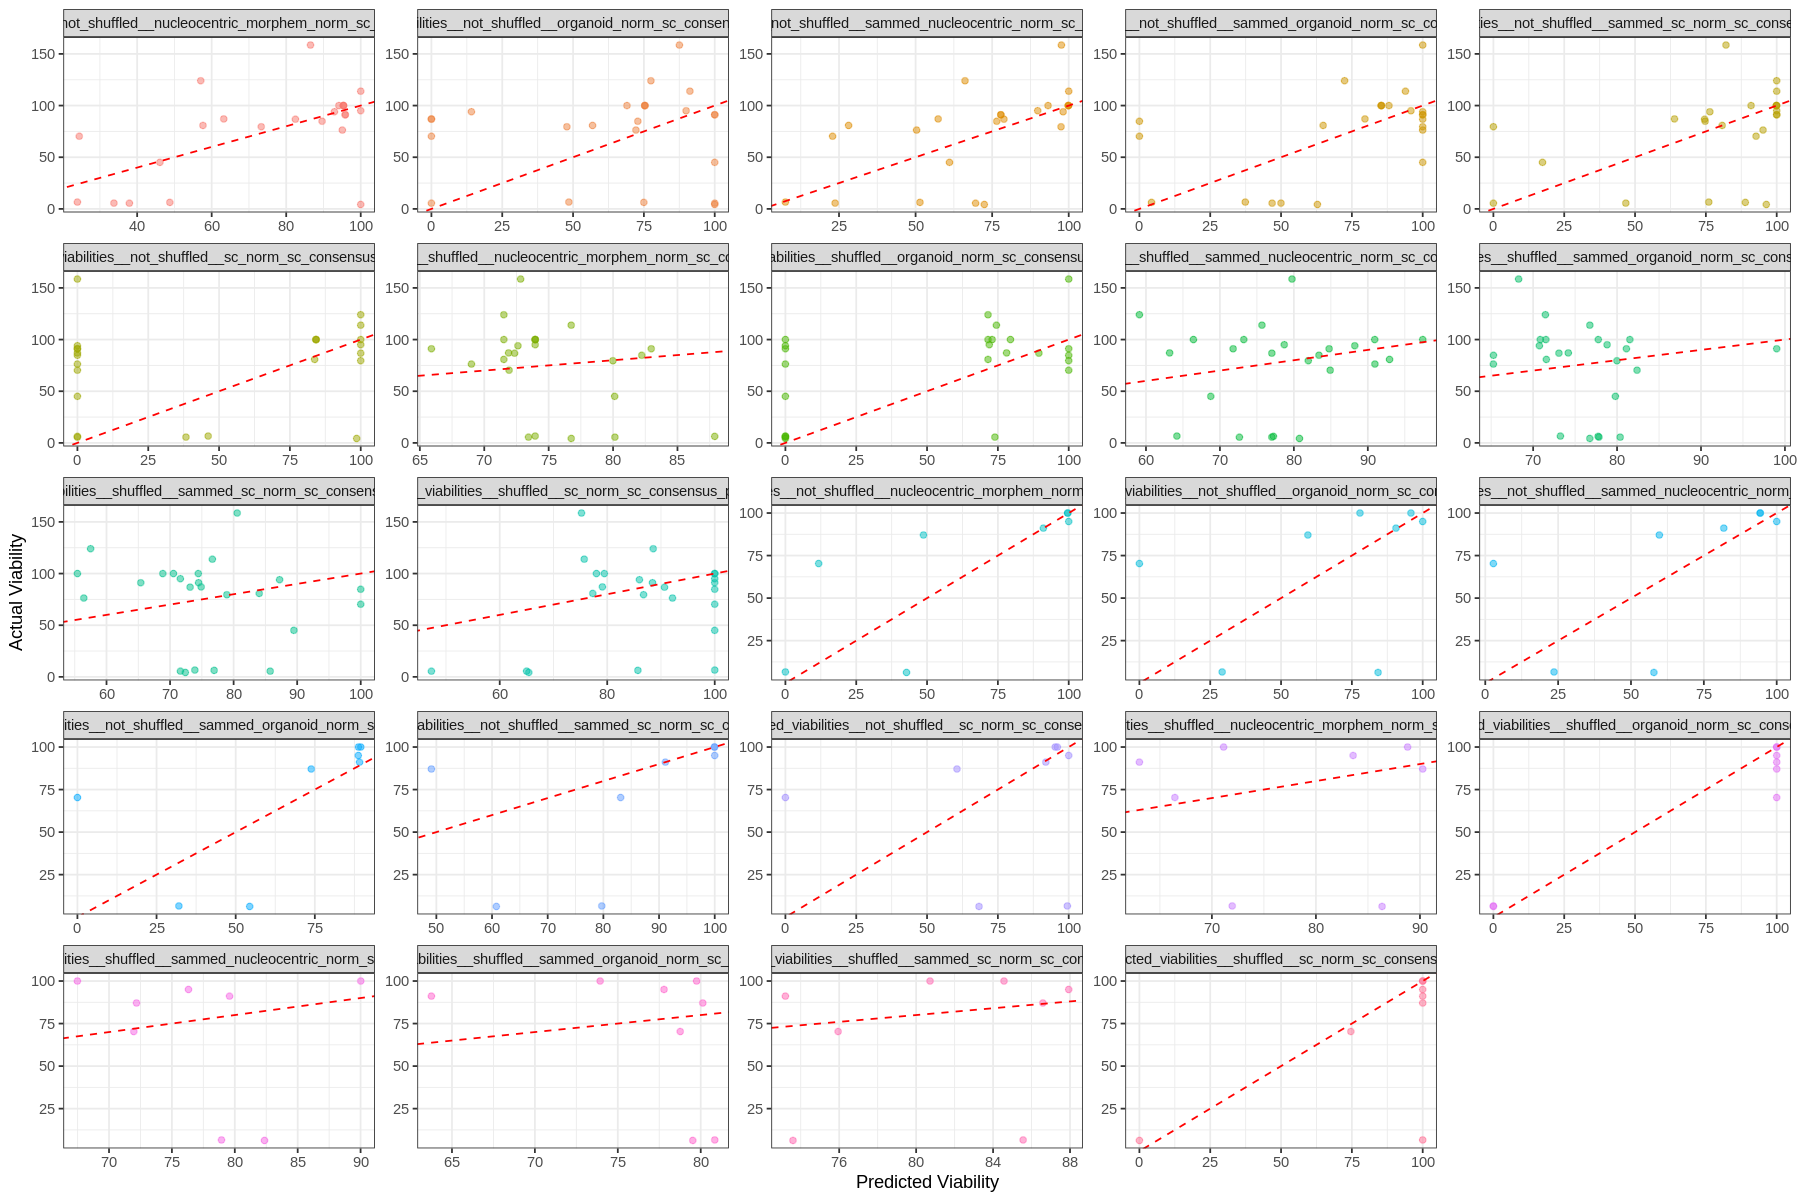

In [11]:
# predicted viabilities plot
predicted_viabilities_plot <- (
    ggplot(predicted_viabilities_df, aes(x = Predicted_Viability, y = Actual_Viability, color = profile_type))
    + geom_point(alpha = 0.5)
    + geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red")
    + facet_wrap(~profile_type, scales = "free")
    + theme_bw()
    + labs(x = "Predicted Viability", y = "Actual Viability")
    + theme(legend.position = "none")
)   
predicted_viabilities_plot